In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np

# Toy example — Bayesian inference for a one-parameter simulator

This folder is the **copyable pattern** for SBI4CogSci tutorial folders
(see `tutorials/CONTRIBUTING.md`). The science here is deliberately tiny:
we simulate data from a one-parameter "cognitive model" (a Gaussian with
unknown mean $\mu$ and known noise $\sigma$) and recover $\mu$ with its
exact conjugate posterior — the simplest possible instance of the
simulate → infer loop this summer school is about.

The notebook is a [marimo](https://marimo.io) file: plain Python, runnable
with a single command (see the README), with its dependencies declared
inline (PEP 723). The committed `.ipynb` next to it is a baked export
that the course website renders — nothing executes at site-build time.

In [ ]:
n_slider = mo.ui.slider(
    5, 200, value=30, step=5, label="Number of simulated observations $n$"
)
n_slider

&lt;marimo-slider data-initial-value=&#x27;30&#x27; data-label=&#x27;&amp;quot;&amp;#92;u003cspan class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;#92;u003e&amp;#92;u003cspan class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;#92;u003eNumber of simulated observations &amp;#92;u003cmarimo-tex class=&amp;#92;&amp;quot;arithmatex&amp;#92;&amp;quot;&amp;#92;u003e||(n||)&amp;#92;u003c/marimo-tex&amp;#92;u003e&amp;#92;u003c/span&amp;#92;u003e&amp;#92;u003c/span&amp;#92;u003e&amp;quot;&#x27; data-start=&#x27;5&#x27; data-stop=&#x27;200&#x27; data-step=&#x27;5&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;

In [ ]:
TRUE_MU = 1.2  # ground-truth parameter the "simulator" uses
SIGMA = 1.0  # known observation noise

_rng = np.random.default_rng(42)
observations = _rng.normal(loc=TRUE_MU, scale=SIGMA, size=n_slider.value)

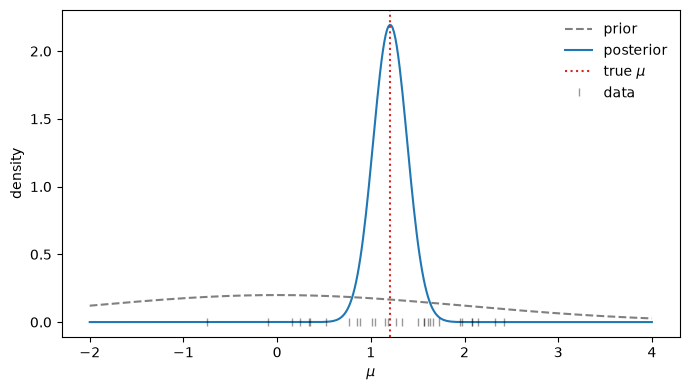

In [ ]:
# Conjugate normal–normal update: prior mu ~ N(0, prior_sd^2), sigma known.
_prior_sd = 2.0
_n = observations.size
post_var = 1.0 / (1.0 / _prior_sd**2 + _n / SIGMA**2)
post_mean = post_var * observations.sum() / SIGMA**2

_grid = np.linspace(-2.0, 4.0, 400)
_prior = np.exp(-0.5 * (_grid / _prior_sd) ** 2) / np.sqrt(
    2 * np.pi * _prior_sd**2
)
_posterior = np.exp(-0.5 * (_grid - post_mean) ** 2 / post_var) / np.sqrt(
    2 * np.pi * post_var
)

_fig, _ax = plt.subplots(figsize=(7, 4))
_ax.plot(_grid, _prior, ls="--", color="gray", label="prior")
_ax.plot(_grid, _posterior, color="C0", label="posterior")
_ax.axvline(TRUE_MU, color="C3", ls=":", label=r"true $\mu$")
_ax.plot(
    observations,
    np.zeros_like(observations),
    "|",
    color="k",
    alpha=0.4,
    label="data",
)
_ax.set_xlabel(r"$\mu$")
_ax.set_ylabel("density")
_ax.legend(frameon=False)
_fig.tight_layout()
_fig

In [ ]:
mo.md(
    f"""
With $n = {n_slider.value}$ observations the posterior is
$\\mu \\mid x \\sim \\mathcal{{N}}({post_mean:.2f}, {post_var**0.5:.2f}^2)$,
concentrating around the true value ${TRUE_MU}$ as you increase the slider —
the whole notebook re-runs reactively.

**To add your own tutorial:** copy this folder, replace the content, keep
the README's structure (one run command), and add a row to
`tutorials/index.qmd`. Every layer used here — marimo, uv, the baked
`.ipynb` site page — is optional; see `tutorials/CONTRIBUTING.md`.
"""
)

With $n = 30$ observations the posterior is
$\mu \mid x \sim \mathcal{N}(1.21, 0.18^2)$,
concentrating around the true value $1.2$ as you increase the slider —
the whole notebook re-runs reactively.

**To add your own tutorial:** copy this folder, replace the content, keep
the README's structure (one run command), and add a row to
`tutorials/index.qmd`. Every layer used here — marimo, uv, the baked
`.ipynb` site page — is optional; see `tutorials/CONTRIBUTING.md`.